In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

## Basic Intitution

In [2]:
# First we create the dataset 

# Sample data: list of transactions
dataset = [['Milk', 'Onion', 'Nut', 'Eggs', 'Yogurt'],
           ['Dill', 'Onion', 'Nut', 'Eggs', 'Yogurt'],
           ['Milk', 'Apple', 'Eggs'],
           ['Milk', 'Unicorn', 'Corn', 'Yogurt'],
           ['Corn', 'Onion', 'Onion', 'Ice cream', 'Eggs']]

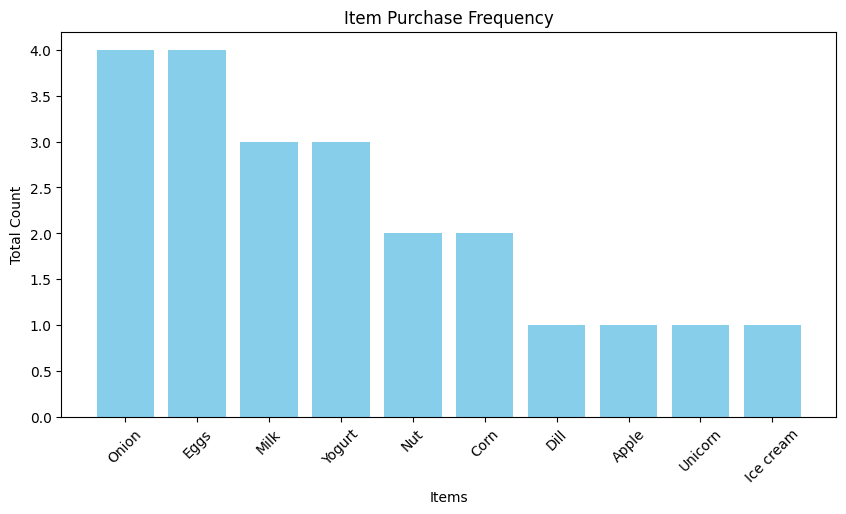

In [31]:
import matplotlib.pyplot as plt
from collections import Counter

# 1. Flatten the list of transactions
all_items = [item for sublist in dataset for item in sublist]

# 2. Count occurrences
item_counts = Counter(all_items)

# 3. Sort for a cleaner plot (highest frequency first)
items, frequencies = zip(*sorted(item_counts.items(), key=lambda x: x[1], reverse=True))

# 4. Draw the Bar Chart
plt.figure(figsize=(10, 5))
plt.bar(items, frequencies, color='skyblue')
plt.title('Item Purchase Frequency')
plt.xlabel('Items')
plt.ylabel('Total Count')
plt.xticks(rotation=45)
plt.show()

In [3]:
# One-hot encoding (converts text to a matrix of True/False)
te = TransactionEncoder()
te_ary = te.fit(dataset).transform(dataset)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [8]:
df

,Apple,Corn,Dill,Eggs,Ice cream,Milk,Nut,Onion,Unicorn,Yogurt
0,False,False,False,True,False,True,True,True,False,True
1,False,False,True,True,False,False,True,True,False,True
2,True,False,False,True,False,True,False,False,False,False
3,False,True,False,False,False,True,False,False,True,True
4,False,True,False,True,True,False,False,True,False,False


In [5]:
# frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)
frequent_itemsets = apriori(df, min_support=0.6, use_colnames=True)

In [6]:
frequent_itemsets

,support,itemsets
0,0.8,(Eggs)
1,0.6,(Milk)
2,0.6,(Onion)
3,0.6,(Yogurt)
4,0.6,"(Onion, Eggs)"


In [7]:
# 'Lift' measures how much more likely Item B is bought when Item A is bought, 
# compared to if they were independent.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])


  antecedents consequents  support  confidence  lift
0     (Onion)      (Eggs)      0.6        1.00  1.25
1      (Eggs)     (Onion)      0.6        0.75  1.25


In [19]:
rules # <-- To avoid extra metrics we used the print before

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Onion),(Eggs),0.6,0.8,0.6,1.00,1.25,1.0,0.12,inf,0.5,0.75,1.000,0.875
1,(Eggs),(Onion),0.8,0.6,0.6,0.75,1.25,1.0,0.12,1.6,1.0,0.75,0.375,0.875
